In [2]:
import pandas as pd

In [3]:
customer_data = pd.read_csv("cleaned_churn_data.csv")

In [4]:
customer_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
customer_data.shape

(10000, 11)

* Overall churn rate: see how many customers left vs the ones who stayed.

In [8]:
customer_data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
customer_data['Exited'].value_counts(normalize = True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

* Visualization to show the difference between customers who stayed and those who churned(left)


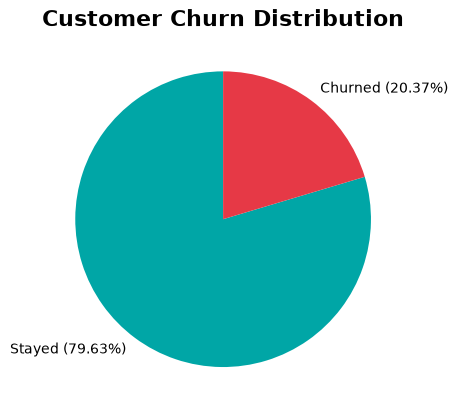

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

churn = customer_data["Exited"].value_counts().sort_index()

total = churn.sum()
percentages = round((churn / total) * 100, 2)

# Building the custom labels

labels = [
    f"{status} ({pct}%)"
    for status, pct in zip(["Stayed", "Churned"], percentages)
]

churn.plot(
    kind = "pie",
    startangle = 90,
    labels = labels,
    colors = ['#00A6A6', '#E63946']
)

plt.title("Customer Churn Distribution", fontsize=16, fontweight="bold")
plt.ylabel("")

plt.show()

* Churn by Geography: Does Customer churn differ across countries?

In [25]:
churn_by_geography = (
    round(customer_data.groupby('Geography')['Exited'].mean().mul(100).reset_index().sort_values(by = 'Exited', ascending = False), 2)
    )

churn_by_geography

,Geography,Exited
1,Germany,32.44
2,Spain,16.67
0,France,16.15


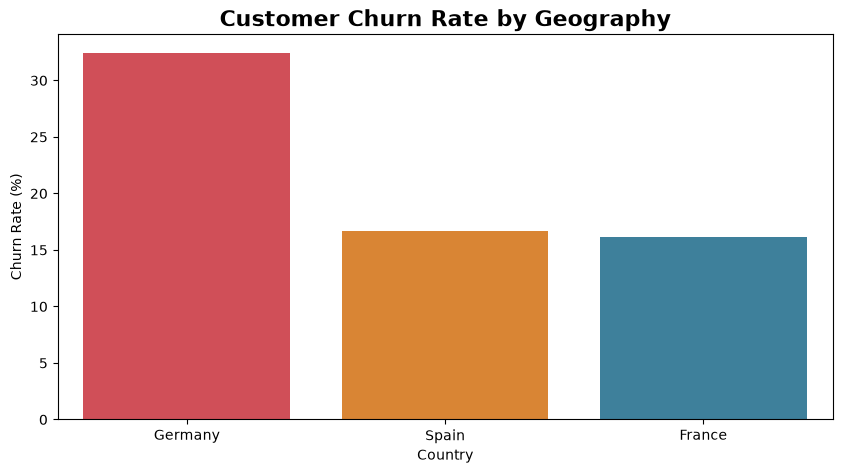

In [138]:
plt.figure(figsize = (10, 5))

sns.barplot(
    data = churn_by_geography,
    x = 'Geography',
    y = 'Exited',
    hue = 'Geography',
    palette = {
        'France': '#2E86AB',
        'Germany': '#E63946',
        'Spain': '#F58518'
    },
    legend = False
)
plt.title('Customer Churn Rate by Geography', fontweight = 'bold', fontsize = 16)
plt.xlabel('Country'),
plt.ylabel('Churn Rate (%)')

plt.show()

* Churn by Gender: Does churn differ between male and female customers?

In [27]:
churn_by_gender = (round(
    customer_data.groupby('Gender')['Exited']
      .mean()
      .mul(100)
      .reset_index(), 2)
)

churn_by_gender

,Gender,Exited
0,Female,25.07
1,Male,16.46


<Figure size 1000x500 with 0 Axes>

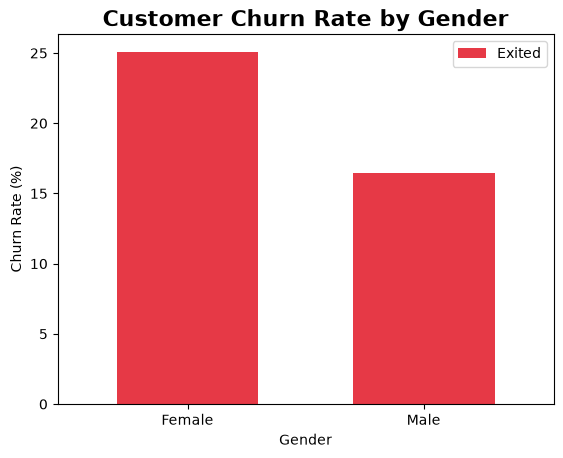

In [195]:
plt.figure(figsize = (10, 5))

churn_by_gender.plot(
    kind = 'bar',
    x = 'Gender',
    color = '#E63946',
    width = 0.6
)

plt.title('Customer Churn Rate by Gender', fontweight = 'bold', fontsize = 16)
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation = 360)

plt.show()

* Churn by Age: Does age affect churn rate?

In [211]:
customer_data['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [39]:
# Create age groups for easy analysis.
customer_data['AgeGroup'] = pd.cut(
    customer_data['Age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

In [258]:
churn_by_age = (round(
    customer_data.groupby('AgeGroup', observed=True)['Exited'].mean().mul(100).reset_index(), 2)
)

churn_by_age

,AgeGroup,Exited
0,18-25,7.53
1,26-35,8.50
2,36-45,19.62
3,46-55,50.57
4,56-65,48.32
5,66+,13.26


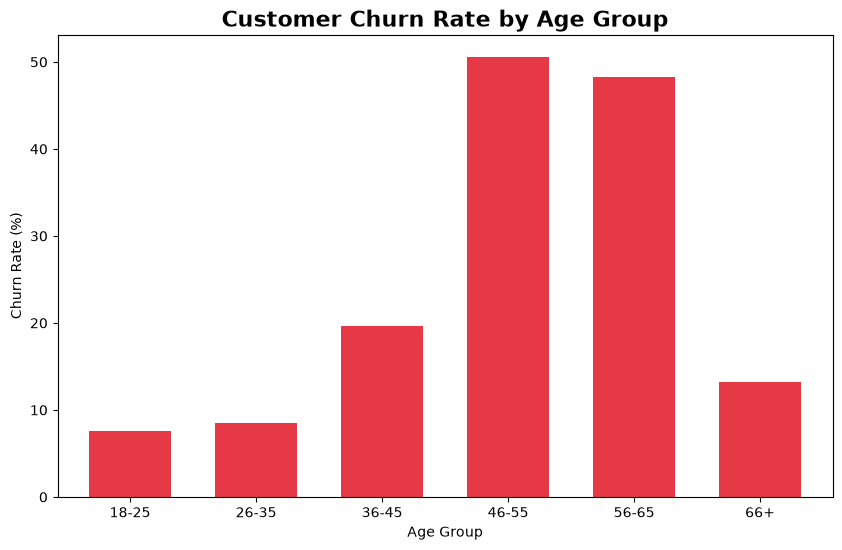

In [ ]:
plt.figure(figsize=(10, 6))

churn_by_age.plot(
    kind = "bar",
    color = "#E63946",
    width = 0.65
)

plt.title('Customer Churn Rate by Age Group', fontsize = 16, fontweight = 'bold')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation = 0, ha = "center")

plt.show()

* Number of Products: Does the number of banking products a customer uses relate to churn?

In [48]:
customer_data.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeGroup'],
      dtype='str')

In [82]:
churn_by_products = (round(
    customer_data.groupby('NumOfProducts')['Exited'].mean().mul(100).reset_index(), 2)
    )

churn_by_products

,NumOfProducts,Exited
0,1,27.71
1,2,7.58
2,3,82.71
3,4,100.00


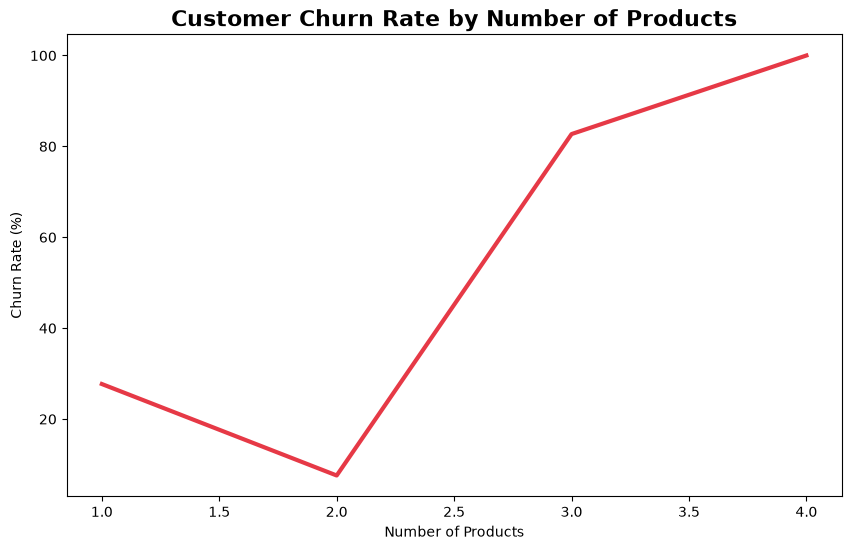

In [210]:
plt.figure(figsize=(10, 6))

plt.plot(
    churn_by_products.index,
    churn_by_products.values,
    marker = None ,
    linewidth = 3,
    color = "#E63946"
)

plt.title("Customer Churn Rate by Number of Products", fontweight = 'bold', fontsize = 16)
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

In [58]:
customer_data['NumOfProducts'].value_counts().sort_index()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

* Churn by Active Membership: Are active bank members less likely to churn?

In [60]:
customer_data.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeGroup'],
      dtype='str')

In [67]:
churn_by_activity = (round
    (customer_data.groupby('IsActiveMember')['Exited'].mean().mul(100).reset_index(), 2)
    )

churn_by_activity

,IsActiveMember,Exited
0,0,26.85
1,1,14.27


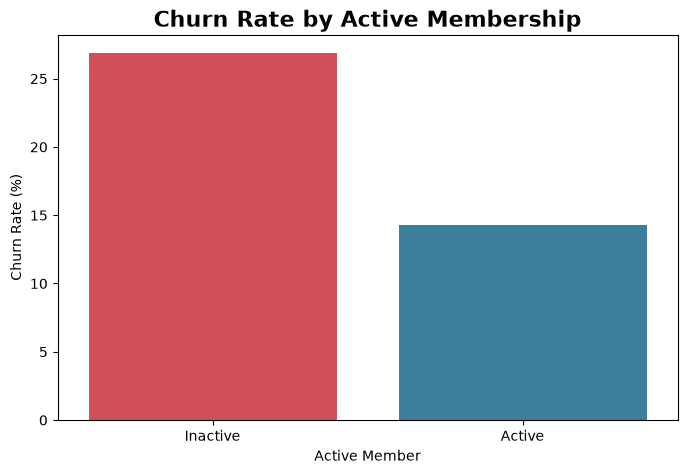

In [78]:
plt.figure(figsize = (8, 5))

ax = sns.barplot(
    data = churn_by_activity,
    x = 'IsActiveMember',
    y = 'Exited',
    hue = 'IsActiveMember',
    palette = {
        0: '#E63946',
        1: '#2E86AB'
    },
    legend = False
)

plt.title("Churn Rate by Active Membership", fontweight = 'bold', fontsize = 16)
plt.xlabel("Active Member")
plt.ylabel("Churn Rate (%)")

plt.xticks([0, 1], ['Inactive', 'Active'])

plt.show()

* Churn by Tenure: Does customer tenure influence churn?

In [79]:
customer_data.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeGroup'],
      dtype='str')

In [83]:
customer_data['Tenure'].describe()

count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Tenure, dtype: float64

In [81]:
churn_by_tenure = (round(
    customer_data.groupby('Tenure')['Exited'].mean().mul(100).reset_index(), 2)
    )

churn_by_tenure

,Tenure,Exited
0,0,23.00
1,1,22.42
2,2,19.18
3,3,21.11
4,4,20.53
5,5,20.65
6,6,20.27
7,7,17.22
8,8,19.22
9,9,21.65


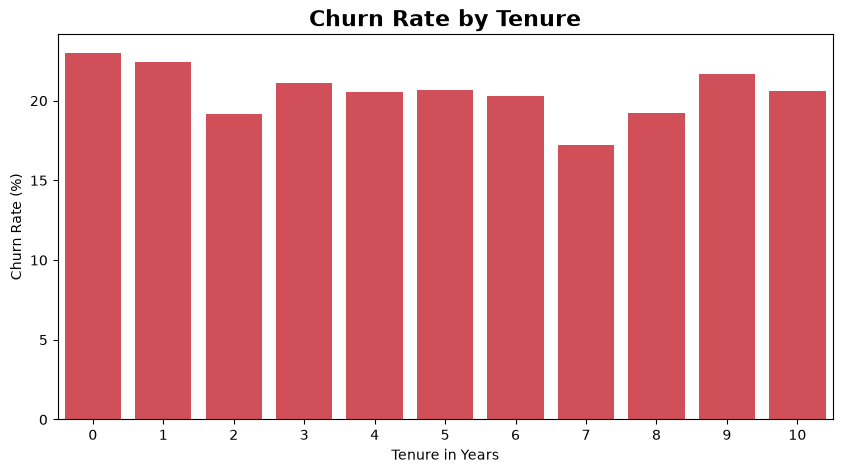

In [131]:
plt.figure(figsize = (10, 5))

ax = sns.barplot(
    data = churn_by_tenure,
    x = 'Tenure',
    y = 'Exited',
    color = '#E63946',
    legend = False
)

plt.title("Churn Rate by Tenure", fontweight = 'bold', fontsize = 16)
plt.xlabel("Tenure in Years")
plt.ylabel("Churn Rate (%)")

plt.show()

* Churn by Account Balance: Are customers with higher account balances more or less likely to churn?

In [92]:
customer_data.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeGroup'],
      dtype='str')

In [94]:
customer_data['Balance'].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

In [95]:
customer_data['BalanceGroup'] = pd.cut(
    customer_data['Balance'],
    bins=[-1, 50000, 100000, 150000, 200000, float('inf')],
    labels=['0–50K', '50K–100K', '100K–150K', '150K–200K', '200K+']
)

In [96]:
churn_by_balance = (round
    (customer_data.groupby('BalanceGroup', observed = True)['Exited'].mean().mul(100).reset_index(), 2)
    )

churn_by_balance

,BalanceGroup,Exited
0,0–50K,14.25
1,50K–100K,19.88
2,100K–150K,25.77
3,150K–200K,21.93
4,200K+,55.88


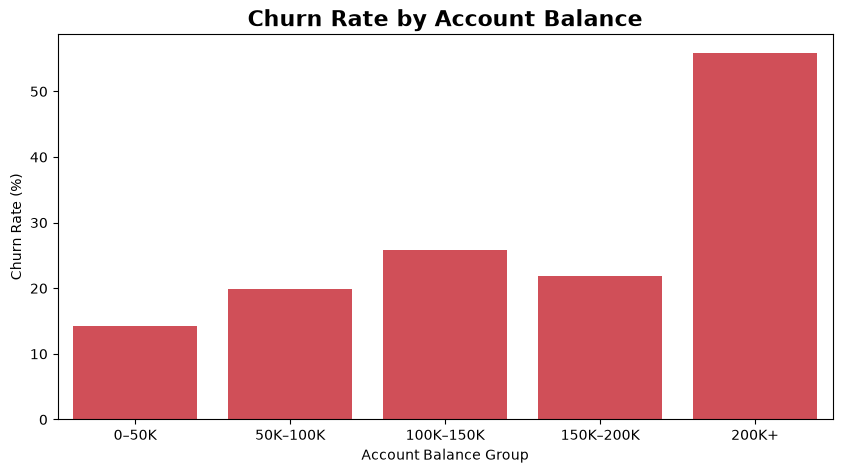

In [129]:
plt.figure(figsize = (10, 5))

ax = sns.barplot(
    data = churn_by_balance,
    x = 'BalanceGroup',
    y = 'Exited',
    color = '#E63946',
    legend = False
)

plt.title("Churn Rate by Account Balance", fontweight = 'bold', fontsize = 16)
plt.xlabel("Account Balance Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [107]:
customer_data['BalanceGroup'].value_counts().sort_index()

BalanceGroup
0–50K        3692
50K–100K     1509
100K–150K    3830
150K–200K     935
200K+          34
Name: count, dtype: int64

* Churn by Credit Score: Does credit score affect customer churn?

In [213]:
customer_data['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [220]:
customer_data['CreditScoreGroup'] = pd.cut(
    customer_data['CreditScore'],
    bins=[300, 500, 600, 700, 800, 850],
    labels=['350–499', '500–599', '600–699', '700–799', '800–850']
)

In [221]:
churn_by_credit = (round
    (customer_data.groupby('CreditScoreGroup', observed=True)['Exited'].mean().mul(100).reset_index(), 2)
    )
    
churn_by_credit

,CreditScoreGroup,Exited
0,350–499,23.64
1,500–599,21.17
2,600–699,19.72
3,700–799,19.91
4,800–850,19.69


In [112]:
customer_data.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeGroup', 'BalanceGroup', 'CreditScoreGroup'],
      dtype='str')

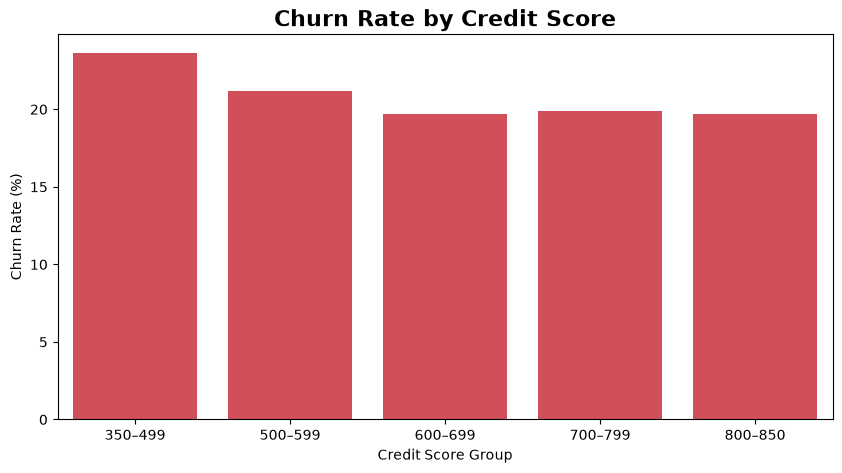

In [128]:
plt.figure(figsize = (10, 5))

ax = sns.barplot(
    data = churn_by_credit,
    x = 'CreditScoreGroup',
    y = 'Exited',
    color = '#E63946',
    legend = False
)

plt.title("Churn Rate by Credit Score", fontweight = 'bold', fontsize = 16)
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")

plt.show()

* Churn by Credit Card: Do customers with credit cards have a higher churn rate?

In [139]:
customer_data.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeGroup', 'BalanceGroup', 'CreditScoreGroup'],
      dtype='str')

In [140]:
churn_by_creditcard = (round
    (customer_data.groupby('HasCrCard')['Exited'].mean().mul(100).reset_index(), 2)
    )

churn_by_creditcard

,HasCrCard,Exited
0,0,20.81
1,1,20.18


In [141]:
customer_data['HasCrCard'].value_counts().sort_index()

HasCrCard
0    2945
1    7055
Name: count, dtype: int64

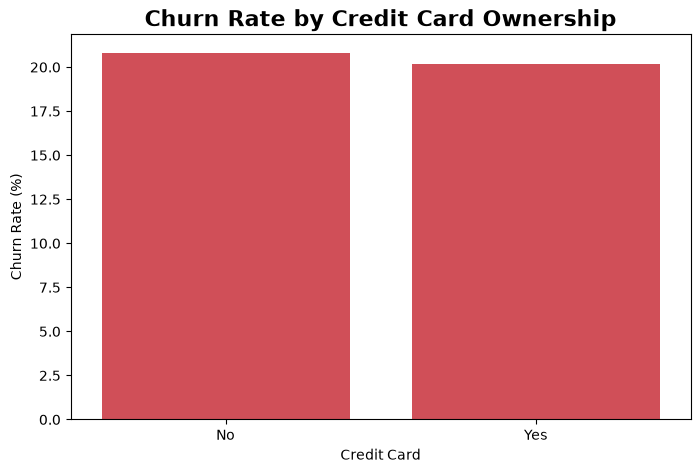

In [223]:
plt.figure(figsize = (8, 5))

ax = sns.barplot(
    data = churn_by_creditcard,
    x = 'HasCrCard',
    y = 'Exited',
    color = '#E63946',
    legend = False
)

plt.title("Churn Rate by Credit Card Ownership", fontweight = 'bold', fontsize = 16)
plt.xlabel("Credit Card")
plt.ylabel("Churn Rate (%)")

plt.xticks([0, 1], ['No', 'Yes'])

plt.show()

* Churn by Salary: Does salary affect customer churn?

In [146]:
customer_data.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeGroup', 'BalanceGroup', 'CreditScoreGroup'],
      dtype='str')

In [147]:
customer_data['EstimatedSalary'].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

In [148]:
customer_data['SalaryGroup'] = pd.cut(
    customer_data['EstimatedSalary'],
    bins=[0, 50000, 100000, 150000, 200000],
    labels=['0–50K', '50K–100K', '100K–150K', '150K–200K']
)

In [150]:
churn_by_salary = (round
    (customer_data.groupby('SalaryGroup', observed=True)['Exited'].mean().mul(100).reset_index(), 2)
    )

churn_by_salary

,SalaryGroup,Exited
0,0–50K,19.93
1,50K–100K,19.87
2,100K–150K,20.23
3,150K–200K,21.47


In [151]:
customer_data['SalaryGroup'].value_counts().sort_index()

SalaryGroup
0–50K        2453
50K–100K     2537
100K–150K    2555
150K–200K    2455
Name: count, dtype: int64

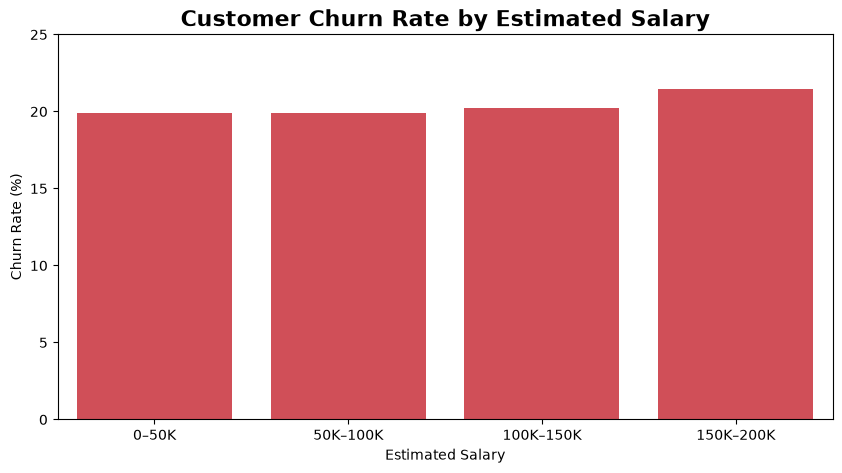

In [153]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data = churn_by_salary,
    x = 'SalaryGroup',
    y = 'Exited',
    color = '#E63946',
    width = 0.8
)

plt.title('Customer Churn Rate by Estimated Salary', fontsize=16, fontweight='bold')
plt.xlabel('Estimated Salary')
plt.ylabel('Churn Rate (%)')

plt.ylim(0, 25)

plt.show()

* Churn by Age and Active Membership

In [155]:
churn_age_activity = (round
    (customer_data.groupby(['AgeGroup', 'IsActiveMember'], observed = True)['Exited'].mean().mul(100).reset_index(), 2)
)

churn_age_activity

,AgeGroup,IsActiveMember,Exited
0,18-25,0,11.11
1,18-25,1,4.33
2,26-35,0,10.80
3,26-35,1,6.27
4,36-45,0,24.22
5,36-45,1,14.63
6,46-55,0,63.61
7,46-55,1,37.15
8,56-65,0,93.85
9,56-65,1,25.49


In [156]:
segment_counts = (
    customer_data.groupby(['AgeGroup', 'IsActiveMember'], observed = True).size().reset_index(name = 'Customers')
)

segment_counts

,AgeGroup,IsActiveMember,Customers
0,18-25,0,288
1,18-25,1,323
2,26-35,0,1740
3,26-35,1,1802
4,36-45,0,1945
5,36-45,1,1791
6,46-55,0,665
7,46-55,1,646
8,56-65,0,179
9,56-65,1,357


In [159]:
churn_age_activity['Membership Status'] = (
    churn_age_activity['IsActiveMember']
    .map({
        0: 'Inactive',
        1: 'Active'
    })
)

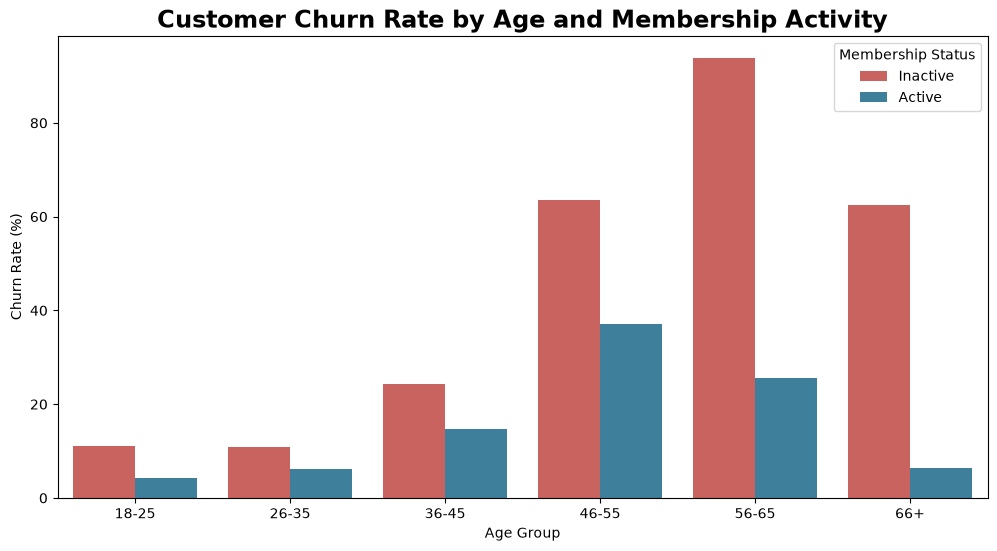

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data = churn_age_activity,
    x = 'AgeGroup',
    y = 'Exited',
    hue = 'Membership Status',
    palette = {
        'Inactive': '#D9534F',
        'Active': '#2E86AB'
    }
)

plt.title('Customer Churn Rate by Age and Membership Activity', fontsize=17, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Membership Status')

plt.show()

Identifying the strongest customer segments

In [249]:
churn_geography_activity = (
    customer_data.groupby(['Geography', 'IsActiveMember'])['Exited'].mean().mul(100).round(2).unstack()
    )

churn_geography_activity

IsActiveMember,0,1
Geography,,
France,21.13,11.50
Germany,41.08,23.72
Spain,23.35,10.75


In [250]:
geography_activity_counts = (customer_data.groupby(['Geography', 'IsActiveMember']).size().reset_index(name='Customers'))

geography_activity_counts

,Geography,IsActiveMember,Customers
0,France,0,2423
1,France,1,2591
2,Germany,0,1261
3,Germany,1,1248
4,Spain,0,1165
5,Spain,1,1312


In [226]:
churn_geography_activity['Membership Status'] = (
    churn_geography_activity['IsActiveMember']
    .map({
        0: 'Inactive',
        1: 'Active'
    })
)

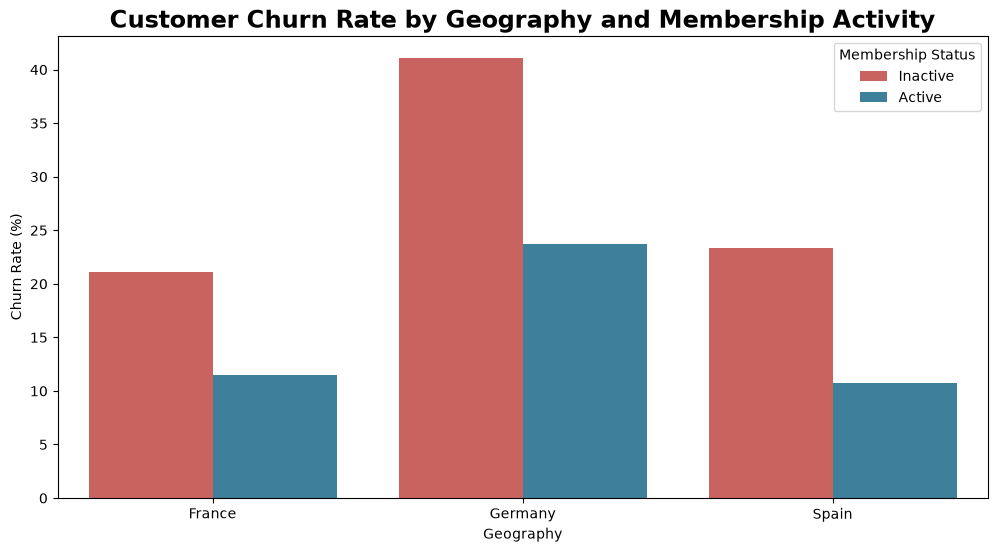

In [227]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data = churn_geography_activity,
    x = 'Geography',
    y = 'Exited',
    hue = 'Membership Status',
    palette = {
        'Inactive': '#D9534F',
        'Active': '#2E86AB'
    }
)

plt.title('Customer Churn Rate by Geography and Membership Activity', fontsize=17, fontweight='bold')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Membership Status')

plt.show()

In [216]:
churn_products_activity = (customer_data.groupby(['NumOfProducts', 'IsActiveMember'])['Exited'].mean().mul(100).round(2).reset_index())

churn_products_activity

,NumOfProducts,IsActiveMember,Exited
0,1,0,36.65
1,1,1,18.92
2,2,0,9.89
3,2,1,5.56
4,3,0,88.24
5,3,1,75.22
6,4,0,100.00
7,4,1,100.00


In [217]:
products_activity_counts = (customer_data.groupby(['NumOfProducts', 'IsActiveMember']).size().reset_index(name='Customers'))

products_activity_counts

,NumOfProducts,IsActiveMember,Customers
0,1,0,2521
1,1,1,2563
2,2,0,2144
3,2,1,2446
4,3,0,153
5,3,1,113
6,4,0,31
7,4,1,29


In [240]:
churn_products_activity['Membership Status'] = (
    churn_products_activity['IsActiveMember']
    .map({
        0: 'Inactive',
        1: 'Active'
    })
)

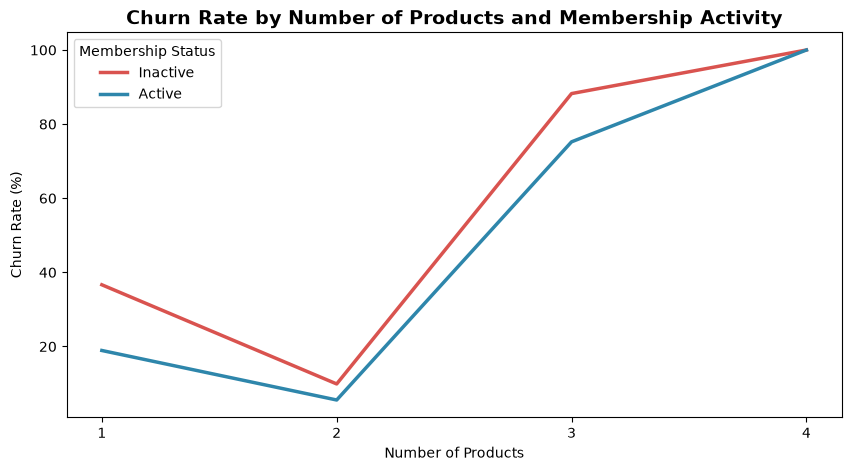

In [247]:
plt.figure(figsize = (10,5))

ax = sns.lineplot(
    data = churn_products_activity,
    x = 'NumOfProducts',
    y = 'Exited',
    hue = 'Membership Status',
    marker = None,
    linewidth = 2.5,
    palette = {
        'Inactive': '#D9534F',
        'Active': '#2E86AB'
    }
)

plt.title("Churn Rate by Number of Products and Membership Activity", fontweight = 'bold', fontsize = 14)
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.xticks([1, 2, 3, 4])

plt.legend(title = "Membership Status")

plt.show()

In [235]:
churn_geography_age = (
    customer_data.groupby(['Geography', 'AgeGroup'], observed=True)['Exited']
      .mean()
      .mul(100)
      .unstack()
)

churn_geography_age

AgeGroup,18-25,26-35,36-45,46-55,56-65,66+
Geography,,,,,,
France,5.228758,5.788635,16.043360,44.388610,44.800000,9.022556
Germany,11.188811,14.800995,31.362196,66.997519,64.864865,25.000000
Spain,8.641975,8.538012,14.830508,41.157556,36.956522,10.447761


In [236]:
geography_age_counts = (
    customer_data.groupby(['Geography', 'AgeGroup'], observed=True)
      .size()
      .reset_index(name='Customers')
)

geography_age_counts

,Geography,AgeGroup,Customers
0,France,18-25,306
1,France,26-35,1883
2,France,36-45,1845
3,France,46-55,597
4,France,56-65,250
5,France,66+,133
6,Germany,18-25,143
7,Germany,26-35,804
8,Germany,36-45,947
9,Germany,46-55,403


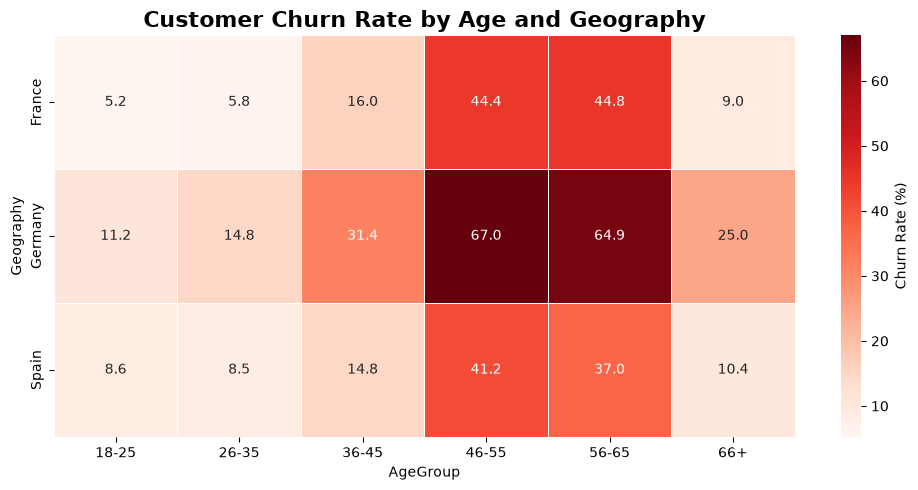

In [239]:
plt.figure(figsize = (10, 5))

sns.heatmap(
    churn_geography_age,
    annot = True,
    fmt = '.1f',
    cmap = 'Reds',
    linewidths = 0.5,
    cbar_kws = {'label': 'Churn Rate (%)'}
)

plt.title("Customer Churn Rate by Age and Geography", fontweight = 'bold', fontsize = 16)

plt.tight_layout()
plt.show()

In [260]:
country_products = (
    customer_data.groupby(["Geography", "NumOfProducts"])["Exited"]
      .mean()
      .mul(100)
      .reset_index()
)

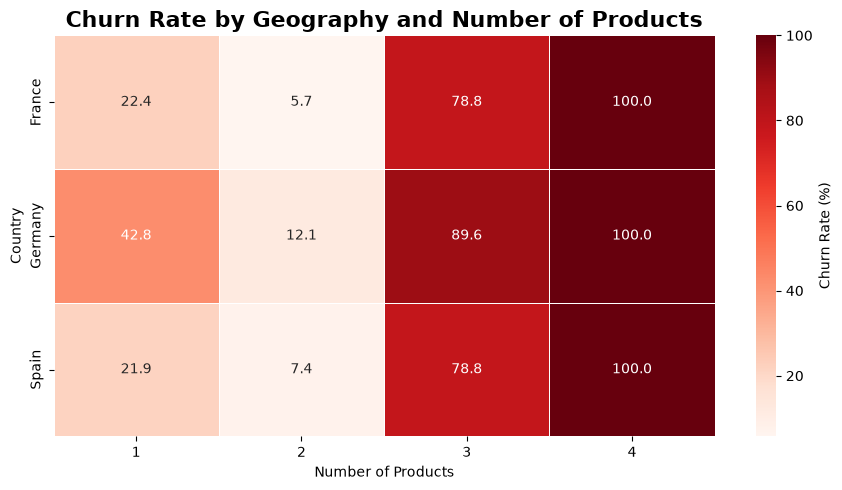

In [261]:
country_products_pivot = country_products.pivot(index = "Geography", columns = "NumOfProducts", values = "Exited")

plt.figure(figsize=(9, 5))

sns.heatmap(
    country_products_pivot,
    annot = True,
    fmt = ".1f",
    cmap = "Reds",
    linewidths = 0.5,
    cbar_kws = {"label": "Churn Rate (%)"}
)

plt.title("Churn Rate by Geography and Number of Products", fontsize = 16, fontweight = "bold")

plt.xlabel("Number of Products")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [262]:
country_tenure = (customer_data.groupby(["Geography", "Tenure"])["Exited"].mean().mul(100).reset_index())

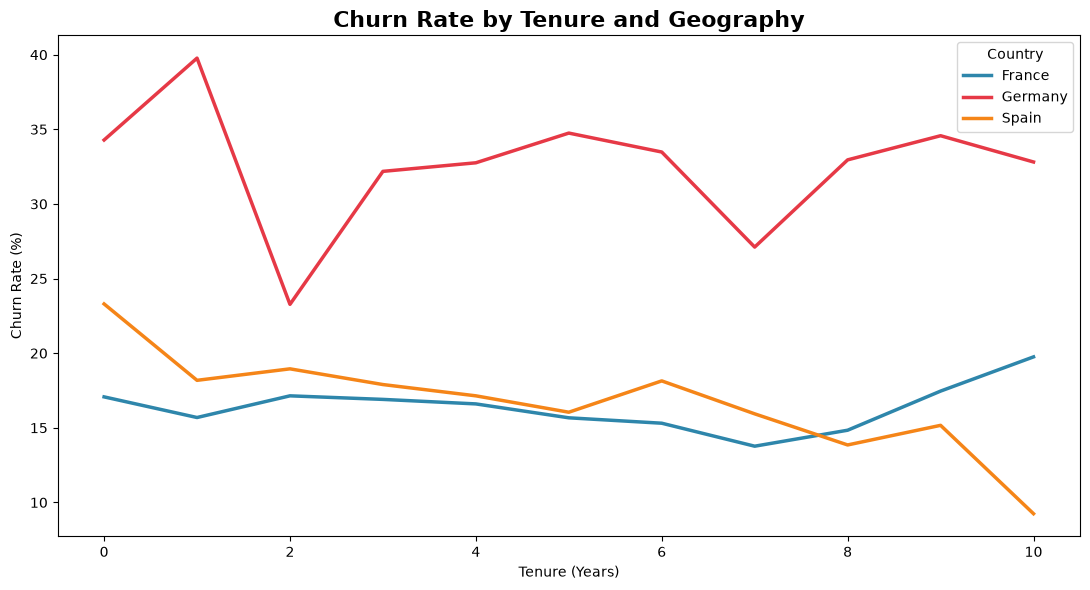

In [266]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data = country_tenure,
    x = "Tenure",
    y = "Exited",
    hue = "Geography",
    palette = {
        'France': '#2E86AB',
        'Germany': '#e63946',
        'Spain': '#F58518'
    },
    marker = None,
    linewidth = 2.5
)

plt.title("Churn Rate by Tenure and Geography", fontsize = 16, fontweight = "bold")

plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")

plt.legend(title = "Country")

plt.tight_layout()
plt.show()

### Findings from Exploratory Analysis

* **Age** : Churn is particularly high among customers aged 46 - 55.
* **Tenure**: Customers with shorter tenure show an elevated churn.
* **Geography**: *Germany* consistently records the highest churn.
* **Membership Activity**: Inactive customers churn considerably more than Active customers.
* **Number of Products**: Customers with 3-4 products have an exceptionally high churn.
* **Credit Score**: The lowest credit score group has the highest churn.
* **Account Balance**: The 200K+ group shows highest churn but the small sample it has means this needs caution.


# **KEY FINDINGS AND BUSINESS INSIGHTS**

#### Key Findings:

**1. Age is a major churn differentiator**

Customers aged between **46-65** have substantially higher churn rates than younger customers. The **46-55** age group reached about **50.6%**, while the **56-65** age group was about **48.3%** overall.

**2. Inactive Customers are much more likely to churn**

Overall churn was **26.85%** for inactive customers versus **14.27%** for active customers. This pattern was also seen across countries and age groups.

**3. Germany is the highest risk Geography**

Germany had an overall churn rate of approximately **32.4%**, compared with **16.2%** in France and **16.7%** in Spain.

**4. Number of Products shows an unusual relationship with churn**

Customers with **3 or 4** products have exceptionally high observed churn. However, this groups are small, so this finding should be treated as a signal requiring further investigation rather than a definitive coclusion.

**5. Short-tenure customers require attention!**

The Tenure analysis showed elevated churn among customers at the beginning of their relationship, particularly at **0 years**. This suggests that early customer experience and onboarding may be important areas worth investigating.

**6. Balance can distinguish some high risk customers**

The **200K** balance group had **55.88%** churn, but only contained 34 customers. The result is therefore interesting but should not be treated as a strong generalizable conclusion.

**7. Some variables appear relatively weak**

Estimated Salary and Credit-card ownership showed only small differences in churn. Credit-card ownership had **20.81%** vs **20.18%** churn, suggesting little separation between the two groups.


**Older, Inactive customers - particularly those aged 46-65 represent a high-risk churn segment, with Germany showing especially high churn among these age groups.**




#### Business Insights:

**1. Customer Engagement is Strongly associated with retention**

Active members consistently have a lower churn than Inactive members. This pattern appears across **age groups** and **countries**, suggesting that customer engagement is an important area for retention efforts.

**Business Implication**: The bank should identify customers whose engagement is declining and encourage meaningful use of their banking products and services.

**2. Older Customers require targeted retention strategies**

Customers aged **46-65** show substantially higher churn than younger customers. The difference becomes particularly pronounced among inactive customers.

**Business Implication**: Retention campaigns should be segmented by age rather than treating the entire customer base the same way.

**3. Germany requires particular attention**: Germany has the highest churn among the three countries, and the problem becomes especially pronounced among customers aged **46-65**.

**Business Implication**: The bank should investigate whether there are country-specific factors contributing to churn, such as customer experience, products, pricing, competition, or service quality.

**4. Product Holdings deserve investigation**

Customers with 3-4 products have extremely high observed churn rates. However, because these groups are relatively small, we should not conclude that 'having more products causes churn'.

**Business Implication**: The bank should investigate these customers further. Multiple products could indicate either strong engagement, or, alternatively, customers experiencing issues across several products.

**5. Early Customer Experience may matter**

The elevated churn among customers with very short tenure suggests that some customers may leave relatively early in their relationship with the bank.
Germany demonstrates consistently elevated churn across customer tenure levels, suggesting that the country's higher churn is not limited to new customers. This indicates that country-specific factors may be contributing to customer attrition.

**Business Implication**: The Onboarding Experience, early Customer Support, Product Education and first-year engagement should be reviewed.

**6. Not every customer characteristic requires intervention**

Estimated salary and credit card ownership showed relatively little variation in charts.

**Business Implications**: These variables should probably receive less attention in broad retention campaigns than factors such as **age, activity, geography, tenure and product usage.**

**Customer churn appears to be concentrated among specific customer segments rather than being evenly distributed across the customer base. Older, inactive customers—particularly those in Germany—represent some of the clearest high-risk groups, while engagement and tenure appear to be important areas for retention efforts.**
